Logistic Regression Model for Predicting an Upset

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import confusion_table
from ISLP.models import summarize
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay
roc_curve_pred = RocCurveDisplay.from_predictions

Model Code

In [12]:
# Load the data
data = pd.read_csv('data/matchups_with_differentials.csv')

# Remove missing and infinite values
data = data.replace([np.inf, -np.inf], np.nan).dropna()

X = data[['diff_AdjEM', 'diff_AdjOE', 'diff_AdjDE', 'diff_AdjTempo', 'seed_diff']]
y = data['upset']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      random_state=314,
                                                      test_size=0.20,
                                                      shuffle=True)

            CONFUSION MATRIX            
                     Predicted No Predicted Yes
Actual No                 112           58
Actual Yes                 35           38


/opt/anaconda3/envs/islp/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/opt/anaconda3/envs/islp/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


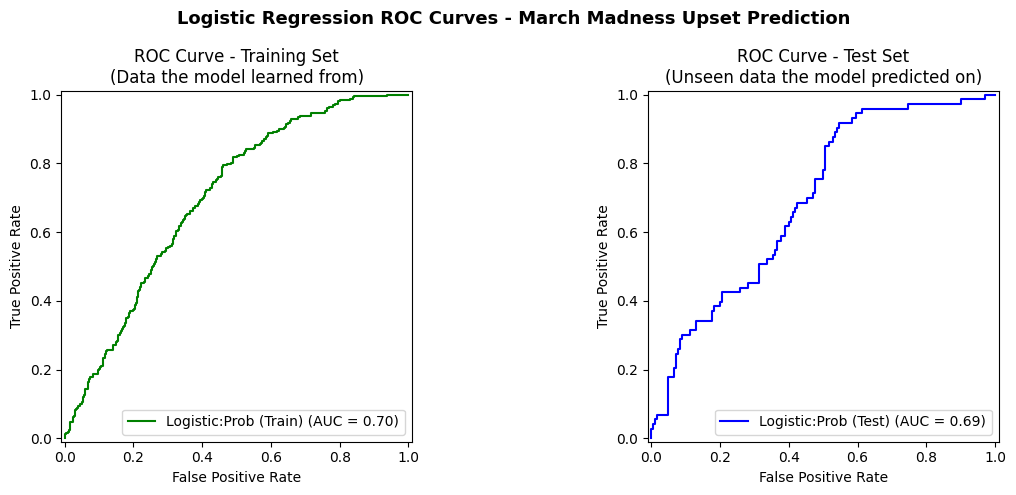

In [16]:
X_train['intercept'] = np.ones(X_train.shape[0])
X_test['intercept'] = np.ones(X_test.shape[0])

glm = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results = glm.fit()
summarize(results)

def predict(X, model):
    predictions_df = pd.DataFrame(model.get_prediction(X).predicted,
                                   columns=['y_hat'], index=X.index)
    return predictions_df['y_hat']

probs_train = predict(X_train, results)
probs_test  = predict(X_test, results)

predictions_train = np.array([True]*len(y_train))
predictions_train[probs_train < 0.3] = False

predictions_test = np.array([True]*len(y_test))
predictions_test[probs_test < 0.3] = False

confusion_table(predictions_test, y_test)

# Truth table
print("=" * 40)
print(f"{'CONFUSION MATRIX':^40}")
print("=" * 40)
print(f"{'':20} {'Predicted No':>8} {'Predicted Yes':>12}")
print(f"{'Actual No':20} {TN:>8} {FP:>12}")
print(f"{'Actual Yes':20} {FN:>8} {TP:>12}")
print("=" * 40)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Train ROC
roc_curve_pred(y_train, probs_train, 
               name='Logistic:Prob (Train)', 
               color='g', ax=ax1)
ax1.set_title('ROC Curve - Training Set\n(Data the model learned from)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')

# Test ROC
roc_curve_pred(y_test, probs_test, 
               name='Logistic:Prob (Test)', 
               color='b', ax=ax2)
ax2.set_title('ROC Curve - Test Set\n(Unseen data the model predicted on)')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')

plt.suptitle('Logistic Regression ROC Curves - March Madness Upset Prediction', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()